In [35]:
 import pandas as pd
 import matplotlib.pyplot as plt

In [ ]:

data = pd.read_csv("salesdaily.csv")
data.head()



,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [12]:
data.describe()

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour
count,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000
mean,5.033683,3.895830,3.880441,29.917095,8.853627,0.593522,5.512262,2.900198,2016.401235,6.344255,275.945869
std,2.737579,2.133337,2.384010,15.590966,5.605605,1.092988,6.428736,2.415816,1.665060,3.386954,1.970547
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2014.000000,1.000000,190.000000
25%,3.000000,2.340000,2.000000,19.000000,5.000000,0.000000,1.000000,1.000000,2015.000000,3.000000,276.000000
50%,4.990000,3.670000,3.500000,26.900000,8.000000,0.000000,4.000000,2.000000,2016.000000,6.000000,276.000000
75%,6.670000,5.138000,5.200000,38.300000,12.000000,1.000000,8.000000,4.000000,2018.000000,9.000000,276.000000
max,17.340000,14.463000,16.000000,161.000000,54.833333,9.000000,45.000000,15.000000,2019.000000,12.000000,276.000000


# Data Cleaning

In [ ]:
# Converting all the sales columns to numeric values and replacing errors with NaN
sales_cols = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]
data[sales_cols] = data[sales_cols].apply(pd.to_numeric, errors="coerce")


#Dropping all the NaN values
required_cols = ["datum", "M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]


data = data.drop_duplicates()

#Dropping all the negative values
data = data[(data[sales_cols] >= 0).all(axis=1)]


print(data.shape)
print(data[sales_cols].describe().T)
#.T transposes the dataframe
data.head()

(2106, 13)
        count       mean        std  min    25%    50%     75%         max
M01AB  2106.0   5.033683   2.737579  0.0   3.00   4.99   6.670   17.340000
M01AE  2106.0   3.895830   2.133337  0.0   2.34   3.67   5.138   14.463000
N02BA  2106.0   3.880441   2.384010  0.0   2.00   3.50   5.200   16.000000
N02BE  2106.0  29.917095  15.590966  0.0  19.00  26.90  38.300  161.000000
N05B   2106.0   8.853627   5.605605  0.0   5.00   8.00  12.000   54.833333
N05C   2106.0   0.593522   1.092988  0.0   0.00   0.00   1.000    9.000000
R03    2106.0   5.512262   6.428736  0.0   1.00   4.00   8.000   45.000000
R06    2106.0   2.900198   2.415816  0.0   1.00   2.00   4.000   15.000000


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


# Question 1 and 2 : What are the total sales quantities for each drug category (ATC code) ; Which individual drug brands have the highest total sales?

Total sales for M01AB: 10600.937083334
Total sales for M01AE: 8204.618645833
Total sales for N02BA: 8172.209000000999
Total sales for N02BE: 63005.40270834
Total sales for N05B: 18645.737499971
Total sales for N05C: 1249.958333333
Total sales for R03: 11608.822916672001
Total sales for R06: 6107.8175


Text(0, 0.5, 'Total Sales')

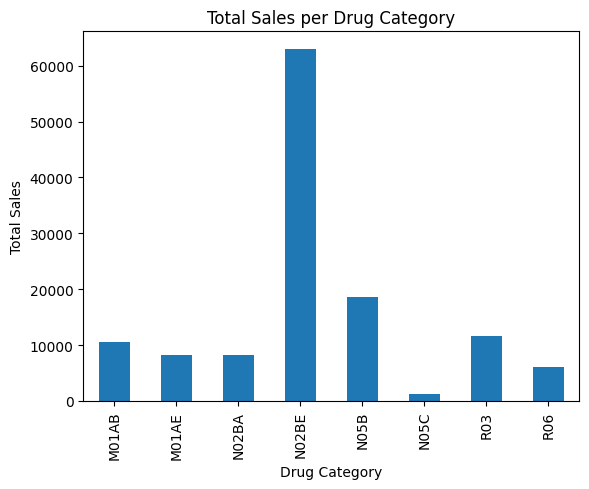

In [34]:
#Simple for loop to get the total sales for each drug category


for col in sales_cols:
    total_sales = data[col].sum()
    print(f"Total sales for {col}: {total_sales}")


# If we want to Plot it

totals = data[sales_cols].sum()
totals.plot(kind='bar')

plt.title("Total Sales per Drug Category")
plt.xlabel("Drug Category")
plt.ylabel("Total Sales")



Here the drug with the more total sales overall is NO2BE

# Question 3 and 4 :Which three drugs have the highest sales in January 2015, July 2016, September 2017; Which drug has sold the most often in 2017?

In [53]:
 # First we extract year and month from your date column
data["year"] = data["datum"].dt.year
data["month"] = data["datum"].dt.month

# lets define a function
def top3_month(year, month):
    # Filter the data for the given year and month with a boolean
    filter = (data["year"] == year) & (data["month"] == month)
    #apply filter and sum each of the sales columns
    totals = data.loc[filter, sales_cols].sum()
    #sort the values in descending order and return the top 3
    return totals.sort_values(ascending=False).head(3)
    
print("Top 3 drugs for January 2015:")    
print(top3_month(2015, 1))   # January 2015
print("Top 3 drugs for July 2016:")
print(top3_month(2016, 7))   # July 2016
print("Top 3 drugs for September 2017:")
print(top3_month(2017, 9))   # September 2017









Top 3 drugs for January 2015:
N02BE    1044.24
N05B      463.00
R03       177.25
dtype: float64
Top 3 drugs for July 2016:
N02BE    652.362000
N05B     240.000000
M01AB    194.528333
dtype: float64
Top 3 drugs for September 2017:
N02BE    863.75
N05B     223.00
R03      139.00
dtype: float64


In [ ]:

# Now we want to find the drug that has been sold the most often in 2017
sales_cols = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]

# First we filter the data for the year 2017
data_2017 = data[data["year"] == 2017]

# Sum the sales for each drug category in 2017
sales_2017 = data_2017[sales_cols].sum()

# Sort the sales in descending order and get the top 1
Most_sold_2017 = sales_2017.sort_values(ascending=False).head(1)

print("The drug that has been sold the most often in 2017 is:")
print(Most_sold_2017)


The drug that has been sold the most often in 2017 is:
N02BE    9258.804833
dtype: float64


# Question 5 :Which drug category has the highest average daily sales?

In [ ]:
# The thinking here to get all avg of daily sales for each drug category and then compare them as we are not given a specific time period
# it is done where each row = one day


sales_cols = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]

avg_daily = data[sales_cols].mean()

avg_daily = avg_daily.sort_values(ascending=False)

print(avg_daily.head(1))         


N02BE    29.917095
dtype: float64


'N02BE'

# Question 6 : Are respiratory drugs (R03) sold more during specific months?

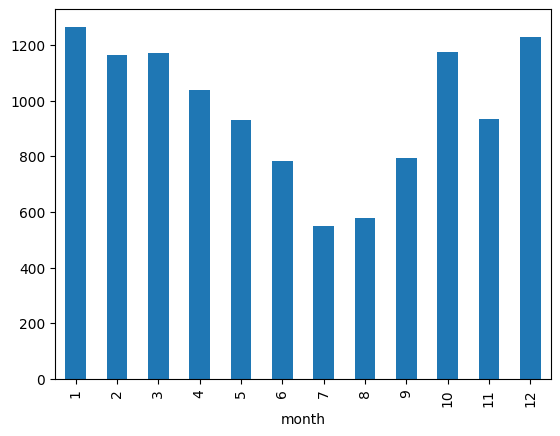

In [ ]:
# Here we want to see if the sales of respiratory drugs (R03) are higher in specific months
# so the reasoning here is to get the sales of R03 for each month and then compare them

r03_monthly = data.groupby("month")["R03"].sum()
r03_monthly.plot(kind="bar")








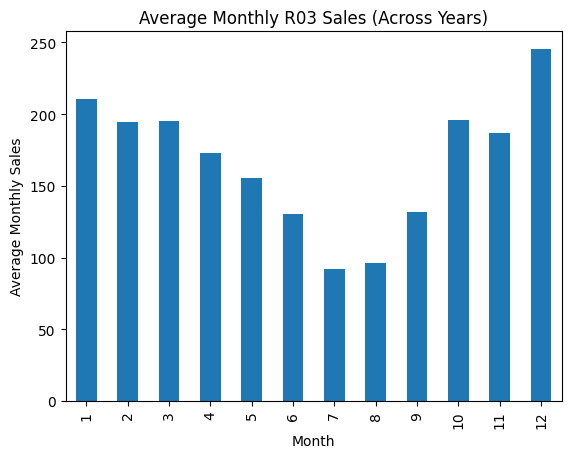

In [70]:
# And if we use the average of each month over the years we get : 

r03_monthly_year = data.groupby(["year", "month"])["R03"].sum()
r03_avg_per_month = r03_monthly_year.groupby("month").mean()

r03_avg_per_month.plot(kind="bar")

plt.title("Average Monthly R03 Sales (Across Years)")
plt.xlabel("Month")
plt.ylabel("Average Monthly Sales")

plt.show()
